<a href="https://colab.research.google.com/github/SithuminiNimthara/Research_Project/blob/main/shoreline_yolov5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install dependencies

In [2]:
!git clone https://github.com/ultralytics/yolov5.git
%cd /content/yolov5
!pip install -qr requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 17851 (delta 28), reused 9 (delta 7), pack-reused 17809 (from 3)
Receiving objects: 100% (17851/17851), 16.99 MiB | 21.19 MiB/s, done.
Resolving deltas: 100% (12159/12159), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 15.3 MB/s eta 0:00:00


In [3]:
!pip install opencv-python-headless pandas matplotlib tqdm pyyaml --quiet

In [4]:
import os

BASE_DIR = "/content/drive/MyDrive/Research"

# Dataset
ZIP_PATH = f"{BASE_DIR}/datasets/shoreline_seg_dataset.zip"
EXTRACT_DIR = f"{BASE_DIR}/shoreline_data/extracted"
TEST_FRAMES_DIR = f"{BASE_DIR}/shoreline_data/test_frames"

# YOLOv5 folders
VERSION = "yolov5"
RUN_NAME = "shoreline_seg_yolov5_v1"

RUNS_DIR = f"{BASE_DIR}/runs/{VERSION}"
MODELS_DIR = f"{BASE_DIR}/models/{VERSION}"
EVAL_DIR = f"{BASE_DIR}/evaluations/{VERSION}"

# Nest points
NEST_CSV = f"{BASE_DIR}/nest_points/nest_points.csv"

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

print("✅ Paths ready")
print("ZIP_PATH      :", ZIP_PATH)
print("EXTRACT_DIR   :", EXTRACT_DIR)
print("RUNS_DIR      :", RUNS_DIR)
print("MODELS_DIR    :", MODELS_DIR)
print("EVAL_DIR      :", EVAL_DIR)
print("NEST_CSV      :", NEST_CSV)

✅ Paths ready
ZIP_PATH      : /content/drive/MyDrive/Research/datasets/shoreline_seg_dataset.zip
EXTRACT_DIR   : /content/drive/MyDrive/Research/shoreline_data/extracted
RUNS_DIR      : /content/drive/MyDrive/Research/runs/yolov5
MODELS_DIR    : /content/drive/MyDrive/Research/models/yolov5
EVAL_DIR      : /content/drive/MyDrive/Research/evaluations/yolov5
NEST_CSV      : /content/drive/MyDrive/Research/nest_points/nest_points.csv


In [5]:
!unzip -qo "{ZIP_PATH}" -d "{EXTRACT_DIR}"
!find "{EXTRACT_DIR}" -maxdepth 5 -name "data.yaml" -print

/content/drive/MyDrive/Research/shoreline_data/extracted/data.yaml


In [6]:
data_yaml = f"{EXTRACT_DIR}/data.yaml"

if not os.path.exists(data_yaml):
    raise FileNotFoundError(f"❌ data.yaml not found: {data_yaml}")

print("✅ Found data.yaml:", data_yaml)

✅ Found data.yaml: /content/drive/MyDrive/Research/shoreline_data/extracted/data.yaml


In [9]:
import yaml

data_yaml = "/content/drive/MyDrive/Research/shoreline_data/extracted/data.yaml"

fixed_data = {
    "path": "/content/drive/MyDrive/Research/shoreline_data/extracted",
    "train": "train/images",
    "val": "valid/images",
    "nc": 1,
    "names": {
        0: "shoreline"
    }
}

with open(data_yaml, "w") as f:
    yaml.dump(fixed_data, f, sort_keys=False)

print("✅ data.yaml fixed successfully")

with open(data_yaml, "r") as f:
    print(f.read())

✅ data.yaml fixed successfully
path: /content/drive/MyDrive/Research/shoreline_data/extracted
train: train/images
val: valid/images
nc: 1
names:
  0: shoreline



In [10]:
import os
import yaml

with open(data_yaml, "r") as f:
    d = yaml.safe_load(f)

root = d["path"]
train_path = os.path.join(root, d["train"])
val_path = os.path.join(root, d["val"])

print("Dataset root:", root)
print("Train path  :", train_path, "->", os.path.exists(train_path))
print("Val path    :", val_path, "->", os.path.exists(val_path))

Dataset root: /content/drive/MyDrive/Research/shoreline_data/extracted
Train path  : /content/drive/MyDrive/Research/shoreline_data/extracted/train/images -> True
Val path    : /content/drive/MyDrive/Research/shoreline_data/extracted/valid/images -> True


Train YOLOv5 segmentation

In [11]:
%cd /content/yolov5

!python segment/train.py \
  --img 640 \
  --batch 16 \
  --epochs 80 \
  --data "{data_yaml}" \
  --weights yolov5n-seg.pt \
  --project "/content/drive/MyDrive/Research/runs/yolov5" \
  --name "shoreline_seg_yolov5_v1" \
  --exist-ok

Streaming output truncated to the last 5000 lines.
      43/79      3.15G    0.02958    0.02906    0.01523          0         33        640:   3% 2/65 [00:00<00:28,  2.18it/s]/content/yolov5/segment/train.py:384: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      43/79      3.15G    0.02859    0.02861    0.01604          0         39        640:   5% 3/65 [00:01<00:29,  2.10it/s]/content/yolov5/segment/train.py:384: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      43/79      3.15G    0.02917    0.02833    0.01529          0         34        640:   6% 4/65 [00:01<00:27,  2.25it/s]/content/yolov5/segment/train.py:384: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.am

In [12]:
import os
import shutil

RUNS_DIR = "/content/drive/MyDrive/Research/runs/yolov5"
RUN_NAME = "shoreline_seg_yolov5_v1"
MODELS_DIR = "/content/drive/MyDrive/Research/models/yolov5"

run_dir = f"{RUNS_DIR}/{RUN_NAME}"
best_pt = f"{run_dir}/weights/best.pt"
save_pt = f"{MODELS_DIR}/shoreline_seg_v5_best.pt"

if not os.path.exists(best_pt):
    raise FileNotFoundError(f"❌ best.pt not found: {best_pt}")

shutil.copy(best_pt, save_pt)

print("✅ Best YOLOv5 model saved to:", save_pt)
print("✅ Training run folder:", run_dir)

✅ Best YOLOv5 model saved to: /content/drive/MyDrive/Research/models/yolov5/shoreline_seg_v5_best.pt
✅ Training run folder: /content/drive/MyDrive/Research/runs/yolov5/shoreline_seg_yolov5_v1


Display training result images

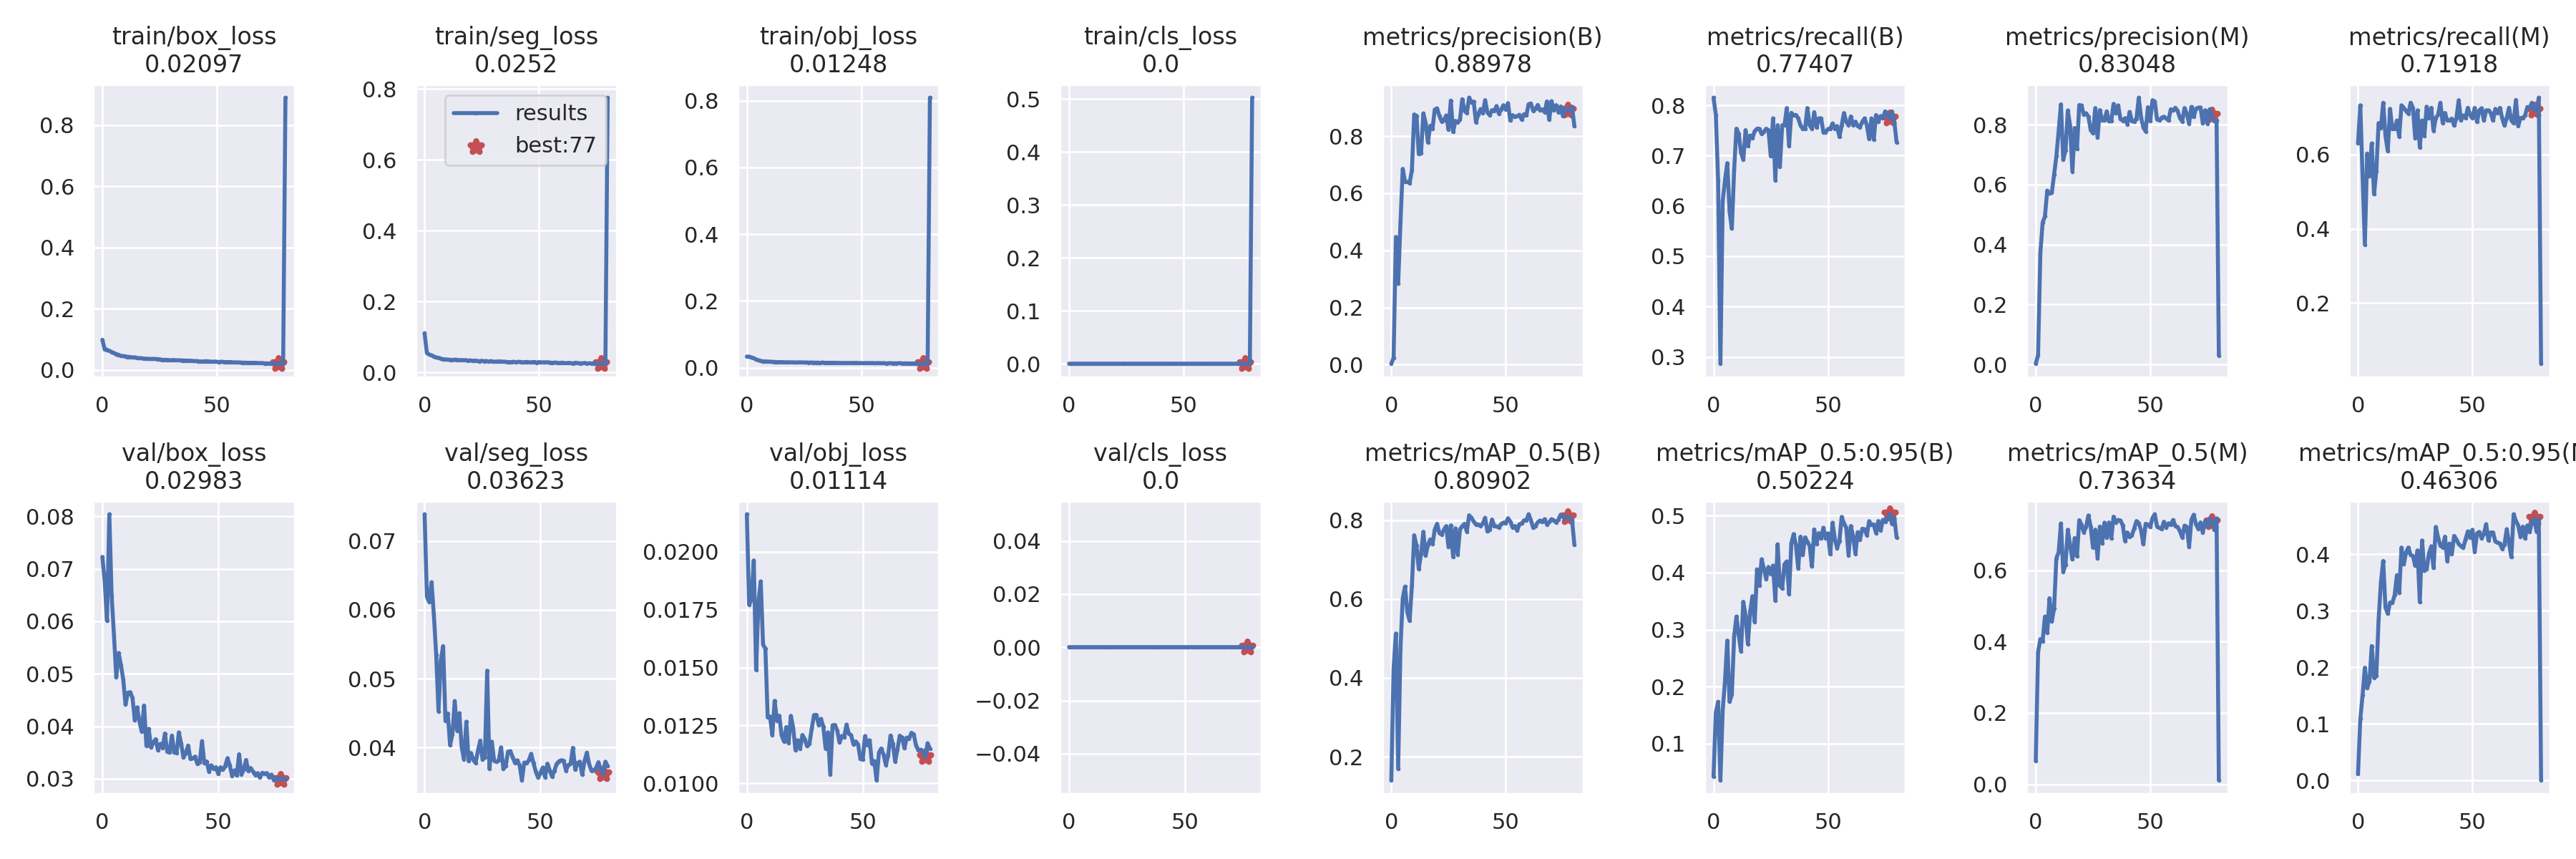

In [13]:
from IPython.display import Image, display
import os

results_img = f"{run_dir}/results.png"
if os.path.exists(results_img):
    display(Image(filename=results_img))
else:
    print("results.png not found")

Read YOLOv5 training metrics

In [17]:
import pandas as pd

csv_path = f"{run_dir}/results.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"❌ results.csv not found: {csv_path}")

df5 = pd.read_csv(csv_path)
# Fix: Strip whitespace from column names
df5.columns = df5.columns.str.strip()

print("✅ Results file loaded")
print(df5.columns.tolist())

df5.head()

✅ Results file loaded
['epoch', 'train/box_loss', 'train/seg_loss', 'train/obj_loss', 'train/cls_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP_0.5(B)', 'metrics/mAP_0.5:0.95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP_0.5(M)', 'metrics/mAP_0.5:0.95(M)', 'val/box_loss', 'val/seg_loss', 'val/obj_loss', 'val/cls_loss', 'x/lr0', 'x/lr1', 'x/lr2']


,epoch,train/box_loss,train/seg_loss,train/obj_loss,train/cls_loss,metrics/precision(B),metrics/recall(B),metrics/mAP_0.5(B),metrics/mAP_0.5:0.95(B),metrics/precision(M),metrics/recall(M),metrics/mAP_0.5(M),metrics/mAP_0.5:0.95(M),val/box_loss,val/seg_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
0,0,0.098901,0.110990,0.033483,0.0,0.003173,0.81507,0.14012,0.042603,0.002453,0.63014,0.065319,0.011112,0.072260,0.073867,0.021621,0.0,0.070462,0.003282,0.003282
1,1,0.068033,0.055080,0.033224,0.0,0.023823,0.78082,0.42338,0.154560,0.030921,0.73288,0.370690,0.108560,0.067707,0.061897,0.017715,0.0,0.040380,0.006534,0.006534
2,2,0.066454,0.050827,0.030614,0.0,0.446880,0.65068,0.51249,0.173340,0.371620,0.54110,0.406810,0.150730,0.060078,0.061118,0.017934,0.0,0.010215,0.009702,0.009702
3,3,0.062711,0.048467,0.028851,0.0,0.282950,0.28649,0.16914,0.035856,0.473650,0.35750,0.400870,0.199090,0.080380,0.064005,0.019626,0.0,0.009629,0.009629,0.009629
4,4,0.059372,0.045624,0.024899,0.0,0.496160,0.60959,0.47470,0.158590,0.493890,0.60274,0.470040,0.163140,0.064907,0.059245,0.014897,0.0,0.009629,0.009629,0.009629


Plot YOLOv5 metrics

In [18]:
print(df5.columns.tolist())

['epoch', 'train/box_loss', 'train/seg_loss', 'train/obj_loss', 'train/cls_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP_0.5(B)', 'metrics/mAP_0.5:0.95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP_0.5(M)', 'metrics/mAP_0.5:0.95(M)', 'val/box_loss', 'val/seg_loss', 'val/obj_loss', 'val/cls_loss', 'x/lr0', 'x/lr1', 'x/lr2']


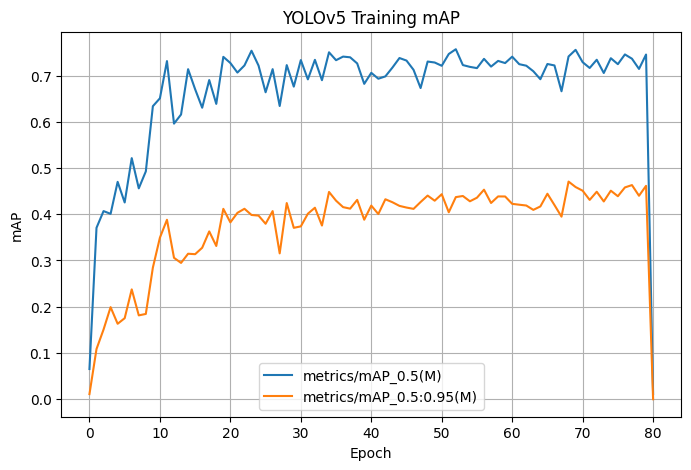

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for col in ["metrics/mAP_0.5(M)", "metrics/mAP_0.5", "metrics/mAP50(M)", "metrics/mAP50(B)"]:
    if col in df5.columns:
        plt.plot(df5["epoch"], df5[col], label=col)

for col in ["metrics/mAP_0.5:0.95(M)", "metrics/mAP_0.5:0.95", "metrics/mAP50-95(M)", "metrics/mAP50-95(B)"]:
    if col in df5.columns:
        plt.plot(df5["epoch"], df5[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("YOLOv5 Training mAP")
plt.legend()
plt.grid(True)
plt.show()

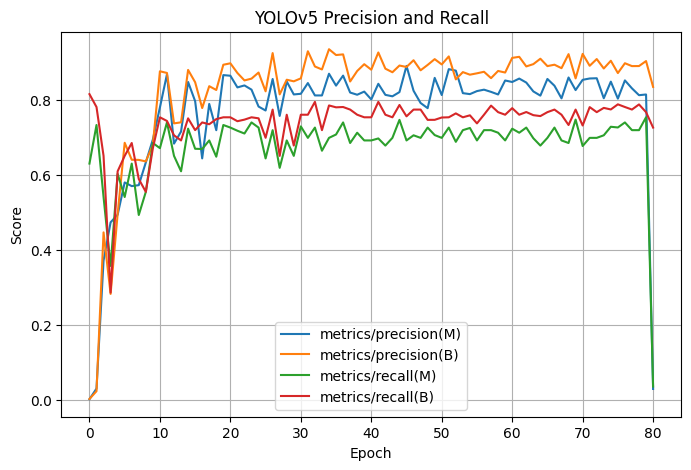

In [20]:
plt.figure(figsize=(8,5))

for col in ["metrics/precision(M)", "metrics/precision", "metrics/precision(B)"]:
    if col in df5.columns:
        plt.plot(df5["epoch"], df5[col], label=col)

for col in ["metrics/recall(M)", "metrics/recall", "metrics/recall(B)"]:
    if col in df5.columns:
        plt.plot(df5["epoch"], df5[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLOv5 Precision and Recall")
plt.legend()
plt.grid(True)
plt.show()

Save plots into evaluations/yolov5/

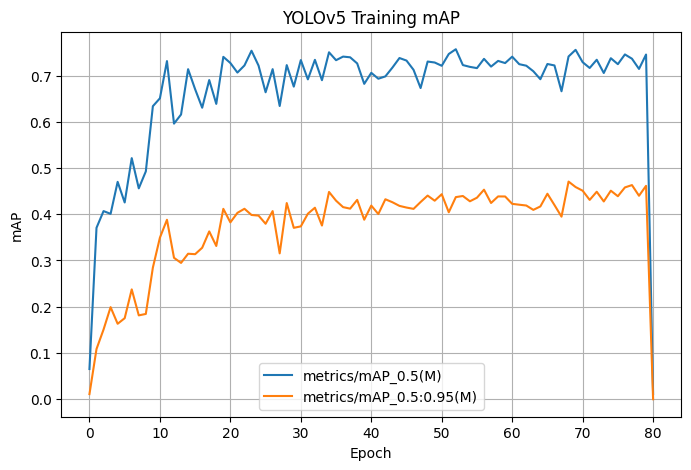

✅ Saved: /content/drive/MyDrive/Research/evaluations/yolov5/yolov5_map_curve.png


In [21]:
plt.figure(figsize=(8,5))

for col in ["metrics/mAP_0.5(M)", "metrics/mAP_0.5", "metrics/mAP50(M)", "metrics/mAP50(B)"]:
    if col in df5.columns:
        plt.plot(df5["epoch"], df5[col], label=col)

for col in ["metrics/mAP_0.5:0.95(M)", "metrics/mAP_0.5:0.95", "metrics/mAP50-95(M)", "metrics/mAP50-95(B)"]:
    if col in df5.columns:
        plt.plot(df5["epoch"], df5[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("YOLOv5 Training mAP")
plt.legend()
plt.grid(True)

map_plot_path = f"{EVAL_DIR}/yolov5_map_curve.png"
plt.savefig(map_plot_path, bbox_inches="tight")
plt.show()

print("✅ Saved:", map_plot_path)

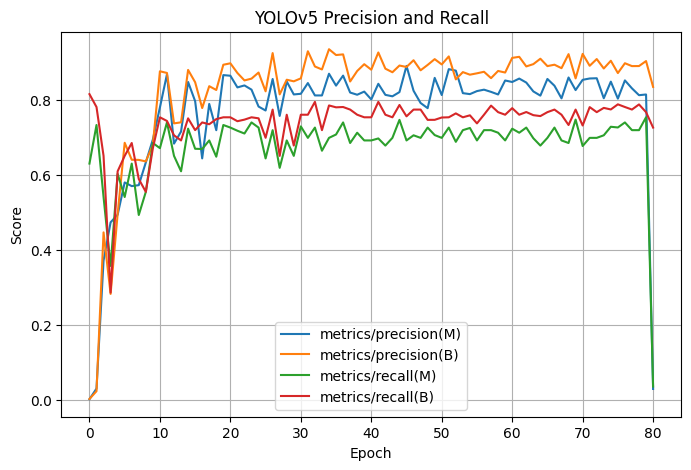

✅ Saved: /content/drive/MyDrive/Research/evaluations/yolov5/yolov5_precision_recall_curve.png


In [22]:
plt.figure(figsize=(8,5))

for col in ["metrics/precision(M)", "metrics/precision", "metrics/precision(B)"]:
    if col in df5.columns:
        plt.plot(df5["epoch"], df5[col], label=col)

for col in ["metrics/recall(M)", "metrics/recall", "metrics/recall(B)"]:
    if col in df5.columns:
        plt.plot(df5["epoch"], df5[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("YOLOv5 Precision and Recall")
plt.legend()
plt.grid(True)

pr_plot_path = f"{EVAL_DIR}/yolov5_precision_recall_curve.png"
plt.savefig(pr_plot_path, bbox_inches="tight")
plt.show()

print("✅ Saved:", pr_plot_path)